# Buscar imágenes en Wikimedia Commons

Notebook interactivo para buscar, evaluar visualmente y descargar imágenes de retratos desde Wikimedia Commons, siguiendo el procedimiento de `docs/obtener-imagenes-wikimedia.md`.

**Flujo:**
1. Buscar candidatos por nombre
2. Inspeccionar tabla de calidad + thumbnails
3. Elegir un índice y descargar
4. Copiar el caption generado para el `aside`

## Configuración

In [1]:
import urllib.request, urllib.parse, json, io, re, os
from IPython.display import display, Image as IPImage, Markdown
from PIL import Image as PILImage

RAIZ = os.path.abspath(os.path.join(os.getcwd(), '..'))

def limpiar_html(texto):
    """Quita etiquetas HTML y recorta texto largo."""
    return re.sub(r'<[^>]+>', '', texto or '').strip()

def buscar_imagenes(termino, limite=20):
    """Busca imágenes en Commons. Devuelve lista de dicts con metadatos."""
    query = urllib.parse.quote(termino)
    url = (
        f'https://commons.wikimedia.org/w/api.php?action=query'
        f'&generator=search&gsrsearch={query}&gsrnamespace=6'
        f'&gsrlimit={limite}&prop=imageinfo'
        f'&iiprop=url|extmetadata|size|thumburl&iiurlwidth=300&format=json'
    )
    req = urllib.request.Request(url, headers={'User-Agent': 'MMFI1-docs/1.0'})
    with urllib.request.urlopen(req) as resp:
        data = json.loads(resp.read())
    candidatos = []
    if 'query' in data:
        for page in data['query']['pages'].values():
            ii = page.get('imageinfo', [{}])[0]
            meta = ii.get('extmetadata', {})
            w, h = ii.get('width', 0), ii.get('height', 0)
            ok = w >= 400 and h >= 500
            candidatos.append({
                'titulo': page['title'],
                'ancho': w,
                'alto': h,
                'calidad': 'ok' if ok else 'baja',
                'artista': limpiar_html(meta.get('Artist', {}).get('value', '?'))[:70],
                'licencia': meta.get('LicenseShortName', {}).get('value', '?'),
                'url': ii.get('url', ''),
                'thumburl': ii.get('thumburl', ''),
            })
    return sorted(candidatos, key=lambda c: (c['calidad'] != 'ok', -(c['ancho'] * c['alto'])))

def mostrar_tabla(candidatos):
    """Muestra tabla Markdown con calidad y dimensiones."""
    filas = [
        f'| {i} | {c["calidad"]} | {c["ancho"]}\u00d7{c["alto"]} | {c["licencia"]} | {c["artista"]} |'
        for i, c in enumerate(candidatos)
    ]
    header = '| # | Calidad | Dimensiones | Licencia | Autor |\n|---|---------|-------------|----------|-------|\n'
    display(Markdown(header + '\n'.join(filas)))

def mostrar_thumbnails(candidatos, solo_ok=False):
    """Muestra thumbnails inline con su \u00edndice."""
    for i, c in enumerate(candidatos):
        if solo_ok and c['calidad'] != 'ok':
            continue
        if not c['thumburl']:
            continue
        display(Markdown(f'**[{i}]** {c["titulo"]} \u2014 {c["ancho"]}\u00d7{c["alto"]} \u2014 {c["licencia"]}'))
        display(IPImage(url=c['thumburl'], width=250))

def descargar(candidatos, indice, destino, max_ancho=800):
    """Descarga, redimensiona y guarda la imagen. Devuelve info para el caption."""
    c = candidatos[indice]
    req = urllib.request.Request(c['url'], headers={'User-Agent': 'MMFI1-docs/1.0'})
    with urllib.request.urlopen(req) as resp:
        raw = resp.read()
    img = PILImage.open(io.BytesIO(raw))
    original = img.size
    if img.size[0] > max_ancho:
        ratio = max_ancho / img.size[0]
        img = img.resize((max_ancho, int(img.size[1] * ratio)), PILImage.LANCZOS)
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    if img.mode == 'RGBA' or img.mode == 'P':
        img = img.convert('RGB')
    img.save(destino, 'JPEG', quality=90, optimize=True)
    tamano_kb = os.path.getsize(destino) // 1024
    print(f'Descargado: {original[0]}\u00d7{original[1]} \u2192 {img.size[0]}\u00d7{img.size[1]} ({tamano_kb} KB)')
    print(f'Guardado en: {destino}')
    display(IPImage(filename=destino, width=300))
    return c

def generar_caption(c, nombre, fechas):
    """Genera el texto del caption para el aside de MyST."""
    commons = f'https://commons.wikimedia.org/wiki/{urllib.parse.quote(c["titulo"].replace(" ", "_"))}'
    return f'{nombre} ({fechas}). Foto: {c["artista"]} ([Wikimedia Commons]({commons}), {c["licencia"]}).'

print('Listo.')

Listo.


---
## Paso 1: Buscar

Editar `BUSQUEDA` con el nombre de la persona y ejecutar.

In [2]:
BUSQUEDA = 'Lene Vestergaard Hau'

candidatos = buscar_imagenes(BUSQUEDA)
print(f'{len(candidatos)} resultados para "{BUSQUEDA}"\n')
mostrar_tabla(candidatos)

20 resultados para "Lene Vestergaard Hau"



| # | Calidad | Dimensiones | Licencia | Autor |
|---|---------|-------------|----------|-------|
| 0 | ok | 10000×5625 | CC BY-SA 3.0 de | Ansgar Koreng |
| 1 | ok | 9427×5303 | CC BY-SA 3.0 de | Ansgar Koreng |
| 2 | ok | 8000×4501 | CC BY-SA 3.0 de | Ansgar Koreng |
| 3 | ok | 6669×4446 | CC BY-SA 4.0 | Dietmar Rabich |
| 4 | ok | 6574×3698 | CC BY-SA 4.0 | Arild Vågen |
| 5 | ok | 6054×4000 | CC BY-SA 4.0 | Roman Eisele |
| 6 | ok | 3738×5597 | CC BY-SA 3.0 | Zinnmann |
| 7 | ok | 4912×3264 | CC BY-SA 4.0 | SH6188 |
| 8 | ok | 3443×4591 | CC BY-SA 4.0 | Dietmar Rabich |
| 9 | ok | 4444×3289 | CC BY-SA 4.0 | Pieter Delicaat |
| 10 | ok | 3024×4032 | CC BY 4.0 | Scotted400 |
| 11 | ok | 4000×3000 | CC BY-SA 4.0 | 姒姓賢寧 |
| 12 | ok | 3728×2854 | CC BY-SA 3.0 | H. Zell |
| 13 | ok | 2448×2448 | CC BY 3.0 | SEM |
| 14 | ok | 1564×1912 | Public domain | Woldemar Hau |
| 15 | ok | 1568×1168 | CC BY 3.0 | Wing1990hk |
| 16 | ok | 902×1080 | Public domain | Woldemar Hau |
| 17 | ok | 427×640 | Public domain | (Photo courtesy of Justin Ide/Harvard News Office) |
| 18 | baja | 314×311 | CC BY-SA 4.0 | Justin Ide/Harvard News Office |
| 19 | baja | 160×240 | Public domain | (Photo courtesy of Justin Ide/Harvard News Office) |

## Paso 2: Inspeccionar thumbnails

Revisar visualmente calidad y orientaci\u00f3n antes de elegir.

In [3]:
mostrar_thumbnails(candidatos, solo_ok=False)

**[0]** File:Paul-Löbe-Haus, Westseite, Berlin-Mitte, 151223, ako.jpg — 10000×5625 — CC BY-SA 3.0 de

**[1]** File:Reichstagsgebäude und Paul-Löbe-Haus, Berlin-Mitte, 170327, ako.jpg — 9427×5303 — CC BY-SA 3.0 de

**[2]** File:Paul-Löbe-Haus, Westseite, Frontalansicht, Berlin-Mitte, 151223, ako.jpg — 8000×4501 — CC BY-SA 3.0 de

**[3]** File:Norderney, Haus Schiffahrt -- 2018 -- 0980-4.jpg — 6669×4446 — CC BY-SA 4.0

**[4]** File:Hau July 2019 01.jpg — 6574×3698 — CC BY-SA 4.0

...

**[15]** File:Hau Kok Tin Hau Temple 201504.jpg — 1568×1168 — CC BY 3.0

**[16]** File:Alexander Hau (by V. Hau).jpg — 902×1080 — Public domain

**[17]** File:Professor Lene Hau in her laboratory at Harvard.jpg — 427×640 — Public domain

**[18]** File:HauLene2007.jpg — 314×311 — CC BY-SA 4.0

**[19]** File:Professor Lene Hau (cropped).jpg — 160×240 — Public domain

---
## Paso 3: Descargar

Elegir el \u00edndice de la imagen deseada (columna `#` de la tabla) y definir el `DESTINO`.
La convenci\u00f3n del proyecto es `Nombre_Apellido.jpg`.

Descargado: 427×640 → 427×640 (72 KB)
Guardado en: /home/glacy/mmfi1/02_numeros_complejos/images/Lene_Hau.png


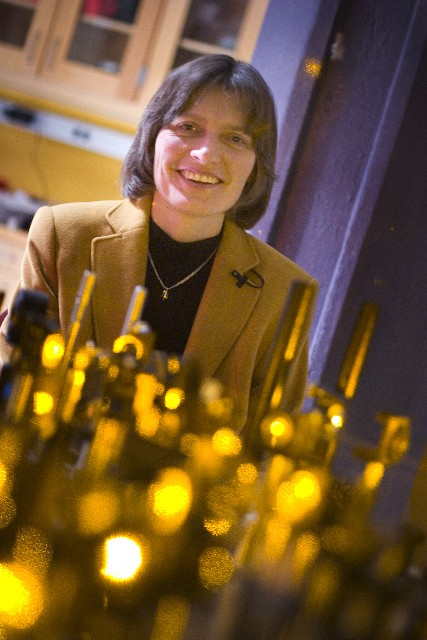

In [4]:
INDICE  = 17  # cambiar seg\u00fan la tabla/thumbnails
DESTINO = os.path.join(RAIZ, '02_numeros_complejos/images/Lene_Hau.png')

info = descargar(candidatos, INDICE, DESTINO, max_ancho=800)

## Paso 4: Caption para el aside

Editar `NOMBRE` y `FECHAS`, luego copiar el texto generado al `{figure}` del aside.

In [5]:
NOMBRE  = 'Lene Vestergaard Hau'
FECHAS  = '1959 - '

caption = generar_caption(info, NOMBRE, FECHAS)
print(caption)

Lene Vestergaard Hau (1959 - ). Foto: (Photo courtesy of Justin Ide/Harvard News Office) ([Wikimedia Commons](https://commons.wikimedia.org/wiki/File%3AProfessor_Lene_Hau_in_her_laboratory_at_Harvard.jpg), Public domain).
